# 📝 Instrucciones

## Prediciendo la diabetes

En el proyecto anterior vimos cómo podíamos utilizar un árbol de decisión para predecir conjuntos de datos relacionados con la clasificación y la regresión. Sin embargo, ¿sabías que podemos mejorar la predicción de un árbol utilizando un **random forest**?

Como hemos estudiado, un random forest es una agrupación de árboles generados con porciones aleatorias de los datos y con criterios también aleatorios. Esta visión nos permitiría mejorar la efectividad del modelo cuando un árbol individual no es suficiente.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el **accuracy**.

Recuerda que el proyecto anterior puedes encontrarlo [aquí](#).

---

### Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).

### Paso 2: Construye un random forest
Una forma de optimizar y mejorar los resultados cuando usamos árboles de decisión es generar un random forest con árboles suficientes de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los dos hiperparámetros que definen al árbol con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

### Paso 3: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [10]:
#Importo todas las librerias que voy a necesitar
import matplotlib.pyplot as plt
import os
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve

In [11]:
# Cargamos el dataset que como recordaremos en el ejericio anterior es el que tiene outliers suavizados lo hacemos a traves de paquete pk1
model_pack = joblib.load('../data/processed/models/diabetes04/diabetes_pack.pkl')
# Creamos nuestras variales y les asignamos los valores del paquete model_dt es el modelo del anterior ejercicio.
model_dt, x_train, x_test, y_train, y_test = model_pack["model"], model_pack["x_train"], model_pack["x_test"], model_pack["y_train"], model_pack["y_test"]
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2.0,84.0,72.0,29.0,125.000,32.3,0.304000,21
618,9.0,112.0,82.0,24.0,125.000,28.2,1.172125,50
346,1.0,139.0,46.0,19.0,95.375,28.7,0.654000,22
294,0.0,161.0,50.0,29.0,125.000,21.9,0.254000,64
231,6.0,134.0,80.0,37.0,150.375,46.2,0.238000,46


In [12]:
#Vamos a provar distintos parametros usando el RandomForestClassifier
path = '../data/processed/models/diabetes04/model_rf.pkl'
#Si el modelo aun no existe se procede a crear
if not os.path.exists(path):
    #Inicializamos el modelo
    model_rf = RandomForestClassifier(random_state=42)
    # Son nuestros parametros de prueba, parecen muchos y tarda en dar resultados pero no conseguia mejorar el modelo anterior y agregue mas parametros.
    parameters = {
        'n_estimators': [50 ,100, 200],
        'max_depth': [None, 5, 7, 10],
        'criterion': ['gini', 'entropy'],
        'class_weight': [{0:1, 1:1}, {0:1, 1:2}, {0:1, 1:3}],
        'min_samples_leaf': [2, 4, 5],
        'min_samples_split': [5, 10, 12],
        'max_features': ['sqrt', 'log2']
    }

    # Buscando, encontre que para modelos con poco support puede ayudar usar RepeatedStratifiedKFold, este mismo intenta que cada arbol que se crea en el forest
    # busque el balance de los datos(no confundir con el balance de clases) 
    cv_strategy = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

    # Ejecutamos el GridSearchCV y le pasamos los parametros y el cv_strategy
    # Aca le digo que use todos los nucleos del procesador "n_jobs=-1" en mi caso que use los 6 nucleos y 12 hilos
    # Aunque estamos tratando temas de salud y es mas importante el recall, probe scoring="precision" porque mi recall ya estaba por encima de 0.80 y el presition estaba muy bajo.
    grid_search = GridSearchCV(estimator = model_rf, param_grid = parameters, cv = cv_strategy, n_jobs = -1, scoring = "precision")
    #Entrenamos
    grid_search.fit(x_train, y_train)
    #Y elejimos el mejor
    model_rf = grid_search.best_estimator_
    #Lo guardamos con la libreria joblib
    joblib.dump(model_rf, path)
else:
    #Carga el modelo si ya existe asi tarda menos
    model_rf = joblib.load(path)
# Imprimimos los mejores parametros
columns = ["n_estimators", "max_depth", "criterion", "class_weight", "min_samples_leaf", "min_samples_split", "max_features"]
parameters_result = pd.DataFrame([model_rf.get_params()])
parameters_result[columns]

,n_estimators,max_depth,criterion,class_weight,min_samples_leaf,min_samples_split,max_features
0,100,5,entropy,"{0: 1, 1: 1}",5,12,sqrt


In [13]:
#Tambien cargamos el modelo anterior para comparar
model_dt.fit(x_train, y_train)
predictions_dt = model_dt.predict_proba(x_test)[:, 1]
umbral=0.4392
predictions_dt = (predictions_dt >= umbral).astype(int)
metrics_dt = classification_report(y_test, predictions_dt, output_dict = True)
print(classification_report(y_test, predictions_dt))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84        99
           1       0.71      0.73      0.72        55

    accuracy                           0.80       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.80      0.80      0.80       154



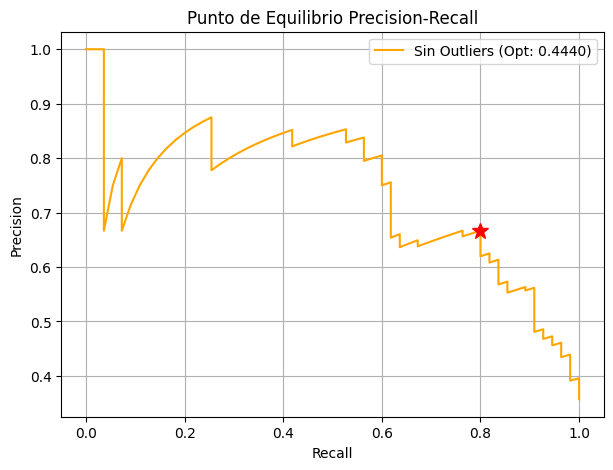

El umbral sugerido es: 0.4440


In [14]:
#Hacemos los mismo que el ejericio anterior y graficamos cual seria el umbral mas equilibrado para el modelo de ramdomforest
predictions_rf = model_rf.predict_proba(x_test)[:, 1]
p, r, t = precision_recall_curve(y_test, predictions_rf)

dist = np.sqrt((1-r)**2 + (1-p)**2)
idx = np.argmin(dist)

opt_t = t[idx] if idx < len(t) else t[-1] 


plt.figure(figsize=(7, 5))
plt.plot(r, p, label=f'Sin Outliers (Opt: {opt_t:.4f})', color = 'orange')
plt.plot(r[idx], p[idx], 'r*', markersize = 12) # Estrella en el punto

plt.title('Punto de Equilibrio Precision-Recall')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(); plt.grid(True); plt.show()

print(f"El umbral sugerido es: {opt_t:.4f}")

In [15]:
# Colocamos el umbral e imprimimos los resultados
umbral=0.444
predictions_rf = (predictions_rf >= umbral).astype(int)
# Con output_dict le decimos que guarde los resultados en un diccionario
metrics_rf = classification_report(y_test, predictions_rf, output_dict=True)
#Aca solo le decimos que lo imprima
print(classification_report(y_test, predictions_rf))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82        99
           1       0.67      0.80      0.73        55

    accuracy                           0.79       154
   macro avg       0.77      0.79      0.78       154
weighted avg       0.80      0.79      0.79       154



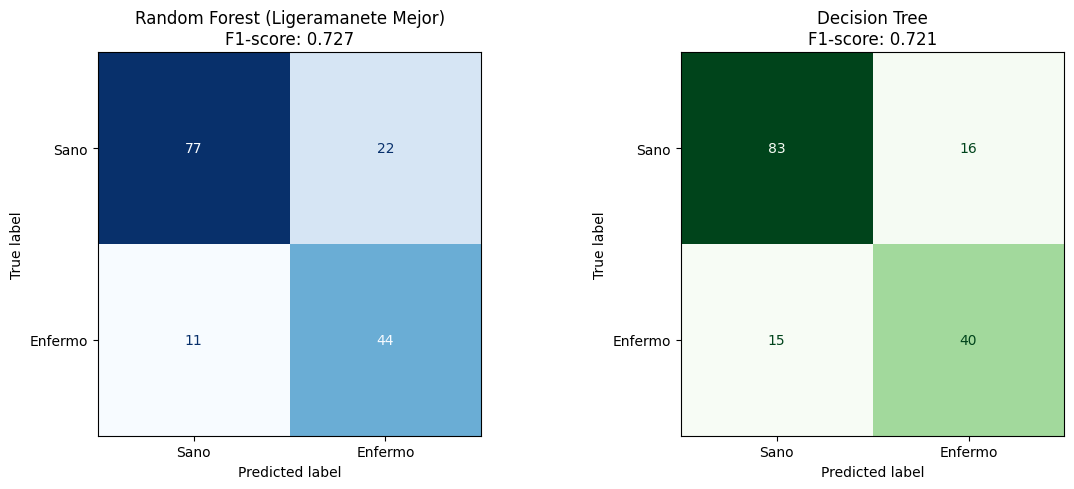

In [17]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest (Ahora)
cm_rf = confusion_matrix(y_test, predictions_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Sano", "Enfermo"])
disp_rf.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"Random Forest (Ligeramanete Mejor)\nF1-score: {metrics_rf['1']['f1-score']:.3f}")

# Decision Tree (Antes)
cm_dt = confusion_matrix(y_test, predictions_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Sano", "Enfermo"])
disp_dt.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"Decision Tree\nF1-score: {metrics_dt['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()

### Conclusiones Finales:
* En el desition tree podemos observar que de 55 pacientes 15 fueron marcados como sanos estando enfermos, mientras que en el ramdom forest logramos reducir ese numero a 11.
* Al tener pocos datos es un poco dificil mejorar los resultados, sin embargo logramos mejorar el recall y f1-score un poco, lo que es importante en medicina ya que es mas importante los reducir los falsos negativos que los falsos positivos, en el primer caso tenemos como consecuenca que un paciente emfermo no recibe tratamiento, en el segundo es una molestia y gastos extras pero se pueden correguir los errores cuando el paciente no corre peligro vital.
* Al final nos quedamos con una presicion del 67% una sensibilidad del 80% y un buen balance f1 de 0.727

In [18]:
model_pack = {
    'model_dt': model_dt,
    'model_rf': model_rf,
    'x_train': x_train,
    'x_test': x_test,
    'y_train': y_train,
    'y_test': y_test
}
path = f"../data/processed/models/diabetes04/"
if not os.path.exists(path):
    os.makedirs(path)
#  Guardamos el paquete
joblib.dump(model_pack, f'{path}diabetes_rf_rt.pkl')


['../data/processed/models/diabetes04/diabetes_rf_rt.pkl']